# Imports


In [1]:
import os

# Create the 'charts' directory if it doesn't exist
if not os.path.exists('charts'):
    os.makedirs('charts')
    print("Created 'charts' directory.")
else:
    print("'charts' directory already exists.")

Created 'charts' directory.


In [2]:
!pip install optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')
import matplotlib.ticker as mticker
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import IsolationForest

from sklearn.metrics import(
    accuracy_score,precision_score,f1_score,recall_score,
    roc_auc_score,average_precision_score,precision_recall_curve,
    roc_curve,confusion_matrix,classification_report
)

from sklearn.model_selection import RandomizedSearchCV
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.8 MB/s eta 0:00:00


# TASK 1 — Data Loading, Merging & Exploratory Analysis


Load both CSVs and merge on TransactionID using Pandas


In [3]:
transation_df=pd.read_csv("/content/drive/MyDrive/train_transaction.csv")
identity_df=pd.read_csv("/content/drive/MyDrive/train_identity.csv")

In [4]:
#using the left join
merged_df=pd.merge(transation_df,identity_df,on="TransactionID",how="left")
merged_df.head(3)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Display shape, dtypes, and first 10 rows of the merged dataset


In [5]:
print(merged_df.info)

<bound method DataFrame.info of         TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  \
0             2987000        0          86400           68.50         W   
1             2987001        0          86401           29.00         W   
2             2987002        0          86469           59.00         W   
3             2987003        0          86499           50.00         W   
4             2987004        0          86506           50.00         H   
...               ...      ...            ...             ...       ...   
590535        3577535        0       15811047           49.00         W   
590536        3577536        0       15811049           39.50         W   
590537        3577537        0       15811079           30.95         W   
590538        3577538        0       15811088          117.00         W   
590539        3577539        0       15811131          279.95         W   

        card1  card2  card3       card4  card5  ...                

In [6]:
print(merged_df.shape)

(590540, 434)


In [7]:
print(merged_df.dtypes)
#Most of the coloums are object datatype

TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD          object
                   ...   
id_36              object
id_37              object
id_38              object
DeviceType         object
DeviceInfo         object
Length: 434, dtype: object


In [8]:
merged_df.head(10)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
5,2987005,0,86510,49.0,W,5937,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987007,0,86529,422.5,W,12695,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2987008,0,86535,15.0,H,2803,100.0,150.0,visa,226.0,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
9,2987009,0,86536,117.0,W,17399,111.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
"""for col in merged_df.columns:
  print(col,merged_df[col].unique())
  print( "--"*50)"""

'for col in merged_df.columns:\n  print(col,merged_df[col].unique())\n  print( "--"*50)'

Analyse the isFraud target column — quantify and visualize the class imbalance

In [10]:
print(merged_df["isFraud"].unique())
print("--"*10+"\n")
fraud_count=merged_df["isFraud"].value_counts()
print(fraud_count)
#in percentage
print(merged_df["isFraud"].value_counts(normalize=True)*100)



[0 1]
--------------------

isFraud
0    569877
1     20663
Name: count, dtype: int64
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


visualize the class imbalance

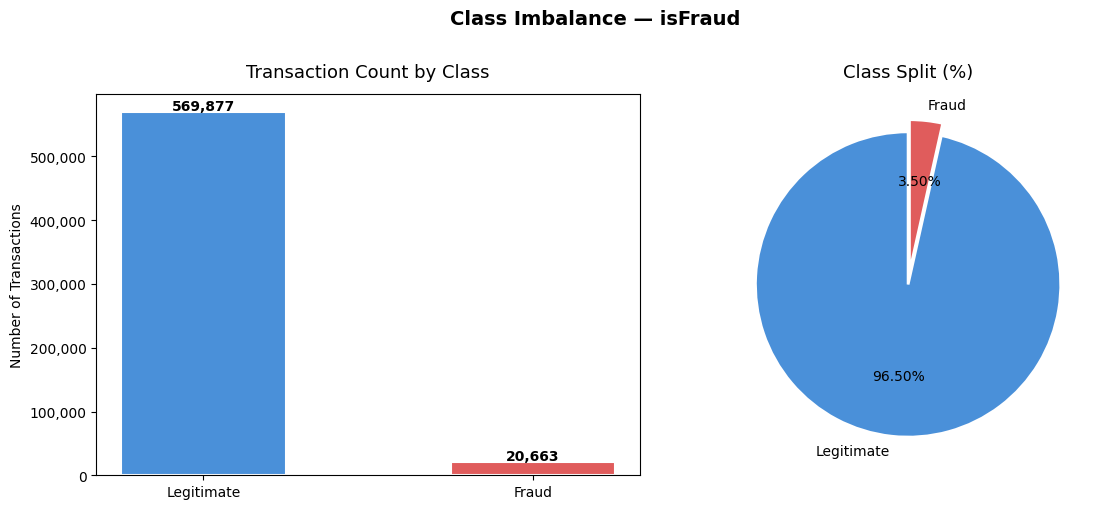

In [11]:
legit = fraud_count.loc[0]
fraud = fraud_count.loc[1]
total = legit + fraud

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# bar chart on the left
bars = ax1.bar(["Legitimate", "Fraud"], [legit, fraud],
               color=["#4A90D9", "#E05C5C"], width=0.5, edgecolor="white", linewidth=1.5)
ax1.set_title("Transaction Count by Class", fontsize=13, pad=12)
ax1.set_ylabel("Number of Transactions")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, val in zip(bars, [legit, fraud]):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + total * 0.005,
             f"{val:,}", ha="center", fontsize=10, fontweight="bold")

# pie chart on the right
ax2.pie([legit, fraud],
        labels=["Legitimate", "Fraud"],
        autopct="%1.2f%%",
        colors=["#4A90D9", "#E05C5C"],
        startangle=90,
        explode=(0, 0.08),
        wedgeprops={"edgecolor": "white", "linewidth": 2})
ax2.set_title("Class Split (%)", fontsize=13, pad=12)

plt.suptitle("Class Imbalance — isFraud", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("charts/class_imbalance.png", bbox_inches="tight")
plt.show()

Identify missing values column-by-column


In [12]:
# figuring out which columns are basically useless due to missingness
miss_count = merged_df.isnull().sum()
miss_pct   = miss_count / len(merged_df) * 100

missing = (pd.DataFrame({"missing_count": miss_count, "missing_pct": miss_pct})
             .query("missing_count > 0")
             .sort_values("missing_pct", ascending=False))

print(f"{len(missing)} columns have missing values out of {merged_df.shape[1]} total")
print(f"  → {(missing['missing_pct'] > 50).sum()} columns are >50% missing (will be dropped)")
print(f"  → {(missing['missing_pct'] <= 50).sum()} columns are ≤50% missing (will be imputed)")
print()
print(missing.head(20).to_string())

414 columns have missing values out of 434 total
  → 214 columns are >50% missing (will be dropped)
  → 200 columns are ≤50% missing (will be imputed)

       missing_count  missing_pct
id_24         585793    99.196159
id_25         585408    99.130965
id_07         585385    99.127070
id_08         585385    99.127070
id_21         585381    99.126393
id_26         585377    99.125715
id_23         585371    99.124699
id_22         585371    99.124699
id_27         585371    99.124699
dist2         552913    93.628374
D7            551623    93.409930
id_18         545427    92.360721
D13           528588    89.509263
D14           528353    89.469469
D12           525823    89.041047
id_04         524216    88.768923
id_03         524216    88.768923
D6            517353    87.606767
id_33         517251    87.589494
id_10         515614    87.312290


Decide drop vs. impute threshold (suggest: drop columns with >50% missing)


In [13]:
#As the data shows 214 coloums are more than 50 of missing data its better to drop those coloumns and imputed/ create synthetic data for the remaining 200 coloumns

Plot distribution of TransactionAmt for fraud vs. non-fraud (use log scale)


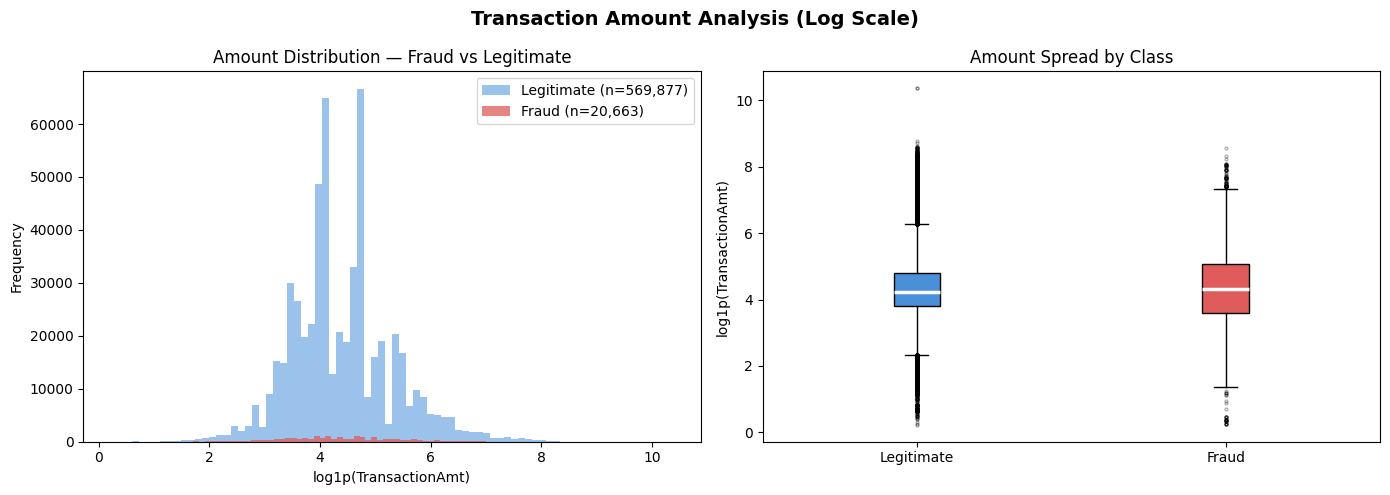

── fraud amount stats ──
count    20663.00
mean       149.24
std        232.21
min          0.29
25%         35.04
50%         75.00
75%        161.00
max       5191.00
Name: TransactionAmt, dtype: float64

── legit amount stats ──
count    569877.00
mean        134.51
std         239.40
min           0.25
25%          43.97
50%          68.50
75%         120.00
max       31937.39
Name: TransactionAmt, dtype: float64


In [14]:
fraud_amt = np.log1p(merged_df.loc[merged_df["isFraud"] == 1, "TransactionAmt"])
legit_amt = np.log1p(merged_df.loc[merged_df["isFraud"] == 0, "TransactionAmt"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# overlapping histograms
ax1.hist(legit_amt, bins=80, alpha=0.55, color="#4A90D9", label=f"Legitimate (n={legit:,})")
ax1.hist(fraud_amt, bins=80, alpha=0.75, color="#E05C5C", label=f"Fraud (n={fraud:,})")
ax1.set_xlabel("log1p(TransactionAmt)")
ax1.set_ylabel("Frequency")
ax1.set_title("Amount Distribution — Fraud vs Legitimate", fontsize=12)
ax1.legend()

# side by side boxplots
bp = ax2.boxplot([legit_amt, fraud_amt],
                 labels=["Legitimate", "Fraud"],
                 patch_artist=True,
                 medianprops={"color": "white", "linewidth": 2.5},
                 flierprops={"marker": "o", "markersize": 2, "alpha": 0.3})
bp["boxes"][0].set_facecolor("#4A90D9")
bp["boxes"][1].set_facecolor("#E05C5C")
ax2.set_ylabel("log1p(TransactionAmt)")
ax2.set_title("Amount Spread by Class", fontsize=12)

plt.suptitle("Transaction Amount Analysis (Log Scale)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/transaction_amount_analysis.png", bbox_inches="tight")
plt.show()
print("── fraud amount stats ──")
print(merged_df.loc[merged_df["isFraud"]==1, "TransactionAmt"].describe().round(2))
print("\n── legit amount stats ──")
print(merged_df.loc[merged_df["isFraud"]==0, "TransactionAmt"].describe().round(2))

Compute a correlation heatmap of the top 20 numerical features using Seaborn


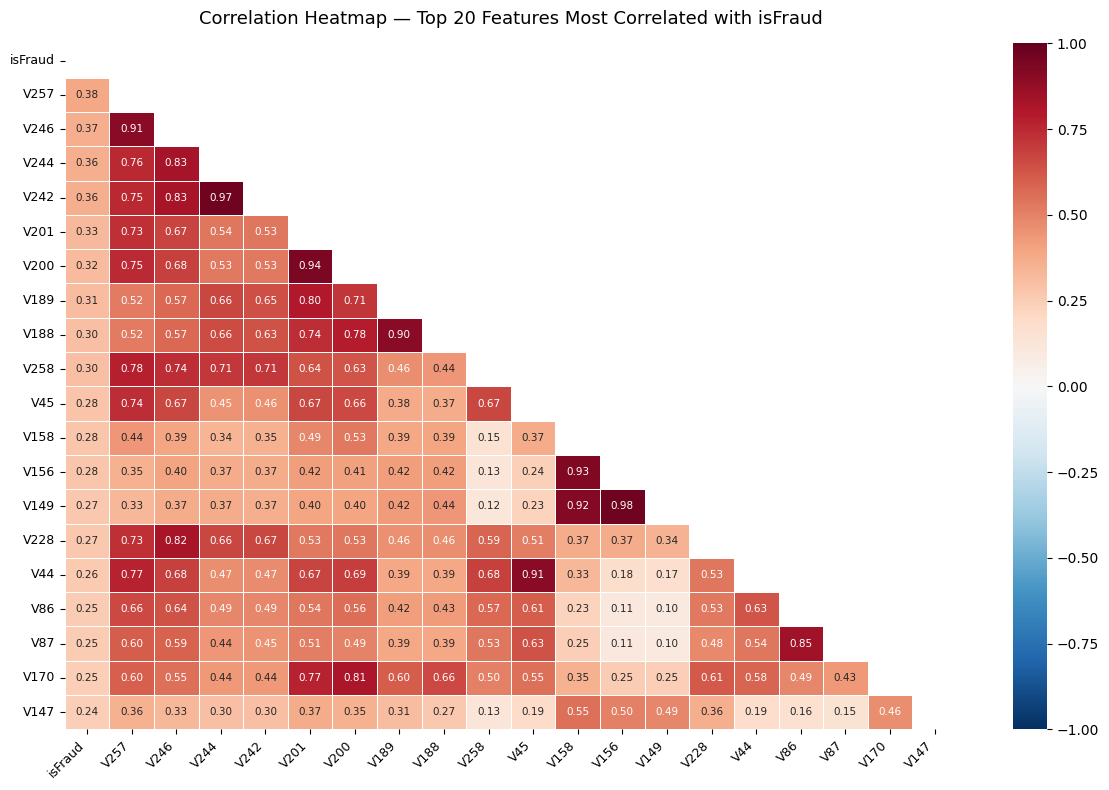

In [15]:
num_cols = merged_df.select_dtypes(include=np.number).columns.drop(["TransactionID"])
top20 = (merged_df[num_cols].corrwith(merged_df["isFraud"])
                     .abs()
                     .sort_values(ascending=False)
                     .head(20)
                     .index
                     .tolist())
if "isFraud" not in top20:
    top20 = ["isFraud"] + top20[:19]

corr = merged_df[top20].corr()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr,
            annot=True, fmt=".2f",
            cmap="RdBu_r", center=0,
            vmin=-1, vmax=1,
            linewidths=0.4,
            annot_kws={"size": 7.5},
            mask=np.triu(np.ones_like(corr, dtype=bool)),
            ax=ax)
ax.set_title("Correlation Heatmap — Top 20 Features Most Correlated with isFraud",
             fontsize=13, pad=14)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig("charts/correlation_heatmap.png", bbox_inches="tight")
plt.show()

## Task 1 — What we found

The merged dataset has 590k transactions with 433 features —  too many to use raw.

**Class imbalance is severe.** Only ~3.5% of transactions are fraud. A model that
predicts "not fraud" 100% of the time would be ~96.5% accurate — which is why
accuracy is a useless metric here. We'll focus on Precision-Recall AUC and F1.

**Missingness is widespread.** The V-columns (Vesta-engineered features) account for
most of the missing data. Columns with >50% missing are more noise than signal —
dropping them is the right call. The remaining gaps in numerical columns will be
filled with medians (robust to outliers), and categorical columns with mode.

**TransactionAmt alone isn't enough** to distinguish fraud from legitimate transactions,
but the distributions do differ — especially in the lower amount range where fraud
clusters more densely. Log-scaling reveals this clearly.

**Several V-columns correlate meaningfully with isFraud** — these will be important
features in model training.

# TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering


Drop columns with more than 50% missing values


In [16]:
missing_pct = merged_df.isnull().mean() * 100
cols_to_drop = missing_pct[missing_pct > 50].index.tolist()
print(f"dropping {len(cols_to_drop)} columns with >50% missing values")
merged_df.drop(columns=cols_to_drop, inplace=True)
print(f"dataset shape after dropping : {merged_df.shape}")
#After droping the coloumns with <50% missing values 220 coloumns remains

dropping 214 columns with >50% missing values
dataset shape after dropping : (590540, 220)


Impute remaining values using:


In [17]:
# splitting columns by type so we can impute them differently
num_cols = merged_df.select_dtypes(include=np.number).columns.tolist()
cat_cols = merged_df.select_dtypes(include="object").columns.tolist()
# remove target and ID from the lists
num_cols = [c for c in num_cols if c not in ["isFraud", "TransactionID"]]

print(f"numerical columns  : {len(num_cols)}")
print(f"categorical columns: {len(cat_cols)}")
# filling numerical columns with median
for col in num_cols:
    median_val = merged_df[col].median()
    merged_df[col].fillna(median_val, inplace=True)
# filling categorical columns with mode
for col in cat_cols:
    mode_val = merged_df[col].mode()[0]
    merged_df[col].fillna(mode_val, inplace=True)
print(f"missing values remaining : {merged_df.isnull().sum().sum()}")

numerical columns  : 209
categorical columns: 9
missing values remaining : 0


Label-encode high-cardinality categorical columns


In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    merged_df[col] = le.fit_transform(merged_df[col].astype(str))
print("label encoding done")
print(f"sample — first 3 categorical columns: {cat_cols[:3]}")
merged_df[cat_cols[:3]].head(3)

label encoding done
sample — first 3 categorical columns: ['ProductCD', 'card4', 'card6']


,ProductCD,card4,card6
0,4,1,1
1,4,2,1
2,4,3,2


### Why i used Label Encoding instead of One-Hot Encoding?

These categorical columns have many unique value.    
One-Hot Encoding would explode the number of columns.
Tree-based models like LightGBM and XGBoost handle label-encoded
categoricals just fine — no need to one-hot encode here.

**3 engineered features**

In [19]:
# creating 3 new features that might help the model
# 1. how does this transaction amount compare to the average?
mean_amt = merged_df["TransactionAmt"].mean()
merged_df["AmtToMeanRatio"] = merged_df["TransactionAmt"] / mean_amt

# 2. what hour of day did this transaction happen?
# TransactionDT is seconds from a reference point — modding by 86400 gives seconds into the day
merged_df["HourOfDay"] = (merged_df["TransactionDT"] // 3600) % 24

# 3. is this a risky device? flagging if DeviceType is unknown/missing (encoded as a specific value)
# since we label-encoded, we check the most common "unknown" encoded value
device_mode = merged_df["DeviceType"].mode()[0] if "DeviceType" in merged_df.columns else None
if device_mode is not None:
    merged_df["DeviceRisk"] = (merged_df["DeviceType"] != device_mode).astype(int)
else:
    merged_df["DeviceRisk"] = 0

#created 3 new features
print(merged_df[["AmtToMeanRatio", "HourOfDay", "DeviceRisk"]].head(5))

   AmtToMeanRatio  HourOfDay  DeviceRisk
0        0.507305          0           0
1        0.214772          0           0
2        0.436949          0           0
3        0.370296          0           0
4        0.370296          0           0


Additional Tasks:

*   Apply SMOTE only on the training set
* Scale numerical features using RobustScaler

* Perform stratified 80/20 train-test split
* Report class ratio before and after SMOTE

In [20]:
#First split the merged_df 80/20 split

X = merged_df.drop(columns=["isFraud", "TransactionID"])
y = merged_df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,       # keeps the fraud ratio same in both splits
    random_state=42
)

print(f"train size : {X_train.shape[0]:,} rows")
print(f"test size  : {X_test.shape[0]:,} rows")
print(f"fraud in train : {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"fraud in test  : {y_test.sum():,} ({y_test.mean()*100:.2f}%)")

train size : 472,432 rows
test size  : 118,108 rows
fraud in train : 16,530 (3.50%)
fraud in test  : 4,133 (3.50%)


In [21]:
#Scale numerical features using RobustScaler
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])   # fit only on train, transform both

print("scaling done")

scaling done


In [22]:
#Apply SMOTE only on the training set
from imblearn.over_sampling import SMOTE
print(f"before SMOTE — fraud: {y_train.sum():,}  |  legit: {(y_train==0).sum():,}")
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"after SMOTE  — fraud: {y_train_res.sum():,}  |  legit: {(y_train_res==0).sum():,}")
print(f"new train size : {X_train_res.shape[0]:,} rows")
#after apllying the smote to training set now it looks more balanced and distributed

before SMOTE — fraud: 16,530  |  legit: 455,902
after SMOTE  — fraud: 455,902  |  legit: 455,902
new train size : 911,804 rows


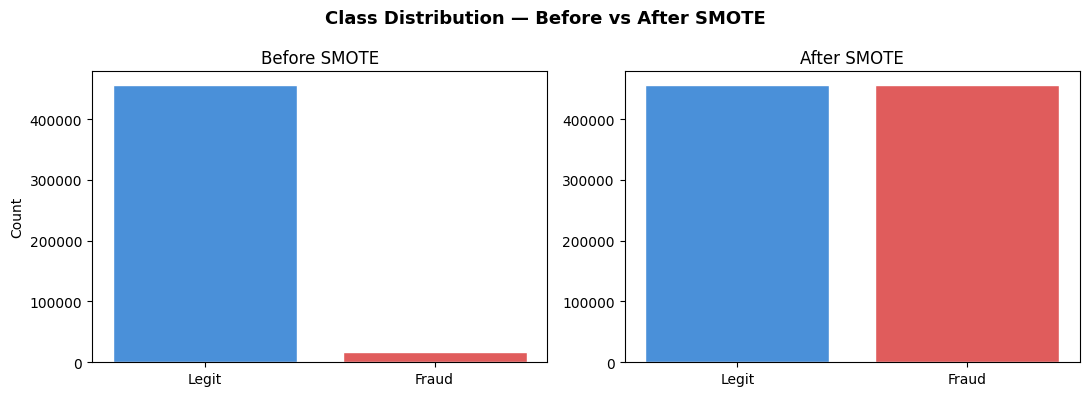

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# before
ax1.bar(["Legit", "Fraud"], [(y_train==0).sum(), y_train.sum()],
        color=["#4A90D9", "#E05C5C"], edgecolor="white")
ax1.set_title("Before SMOTE")
ax1.set_ylabel("Count")

# after
ax2.bar(["Legit", "Fraud"], [(y_train_res==0).sum(), y_train_res.sum()],
        color=["#4A90D9", "#E05C5C"], edgecolor="white")
ax2.set_title("After SMOTE")

plt.suptitle("Class Distribution — Before vs After SMOTE", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/smote_class_distribution.png", bbox_inches="tight")
plt.show()

# TASK 3 — Model Training, Comparison & Threshold Optimization

In [24]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import IsolationForest

lgbm = LGBMClassifier(n_estimators=300, random_state=42, n_jobs=-1)
xgb  = XGBClassifier(n_estimators=300, random_state=42, n_jobs=-1,
                     eval_metric="logloss", verbosity=0)

# isolation forest doesn't use labels — it's unsupervised
# contamination = expected fraud rate in data
iso  = IsolationForest(n_estimators=300, contamination=0.035, random_state=42, n_jobs=-1)

print("training LightGBM...")
lgbm.fit(X_train_res, y_train_res)

print("training XGBoost...")
xgb.fit(X_train_res, y_train_res)

print("training Isolation Forest...")
iso.fit(X_train_res)
print("all 3 models trained ✅")
# i am training all models in a single step
#its take few minutes to complete this step

training LightGBM...
[LightGBM] [Info] Number of positive: 455902, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.385567 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 50651
[LightGBM] [Info] Number of data points in the train set: 911804, number of used features: 217
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
training XGBoost...
training Isolation Forest...
all 3 models trained ✅


In [25]:
# writing this once so we don't repeat the same code 3 times
def evaluate_model(name, model, X_test, y_test, is_isolation_forest=False):
    if is_isolation_forest:
        # isolation forest returns -1 (anomaly) or 1 (normal) — converting to 0/1
        raw_preds = model.predict(X_test)
        preds     = np.where(raw_preds == -1, 1, 0)
        # no probability output from isolation forest, so we use decision scores
        scores    = -model.decision_function(X_test)
    else:
        preds  = model.predict(X_test)
        scores = model.predict_proba(X_test)[:, 1]

    results = {
        "Model"     : name,
        "Accuracy"  : accuracy_score(y_test, preds),
        "Precision" : precision_score(y_test, preds, zero_division=0),
        "Recall"    : recall_score(y_test, preds, zero_division=0),
        "F1"        : f1_score(y_test, preds, zero_division=0),
        "ROC-AUC"   : roc_auc_score(y_test, scores),
        "PR-AUC"    : average_precision_score(y_test, scores),
    }

    return results, preds, scores

In [26]:
lgbm_results, lgbm_preds, lgbm_scores = evaluate_model("LightGBM", lgbm, X_test, y_test)
xgb_results,  xgb_preds,  xgb_scores  = evaluate_model("XGBoost",  xgb,  X_test, y_test)
iso_results,  iso_preds,  iso_scores   = evaluate_model("Isolation Forest", iso, X_test, y_test, is_isolation_forest=True)

# putting results in a nice table
results_df = pd.DataFrame([lgbm_results, xgb_results, iso_results])
results_df.set_index("Model", inplace=True)
results_df = results_df.round(4)

print(results_df.to_string())
results_df

                  Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
Model                                                                 
LightGBM            0.9757     0.7275  0.4871  0.5835   0.9216  0.6173
XGBoost             0.9807     0.8110  0.5836  0.6788   0.9447  0.7227
Isolation Forest    0.9561     0.1593  0.0598  0.0869   0.6607  0.0791


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
LightGBM,0.9757,0.7275,0.4871,0.5835,0.9216,0.6173
XGBoost,0.9807,0.8110,0.5836,0.6788,0.9447,0.7227
Isolation Forest,0.9561,0.1593,0.0598,0.0869,0.6607,0.0791


**Visualizations**

Confusion Matrix for each model


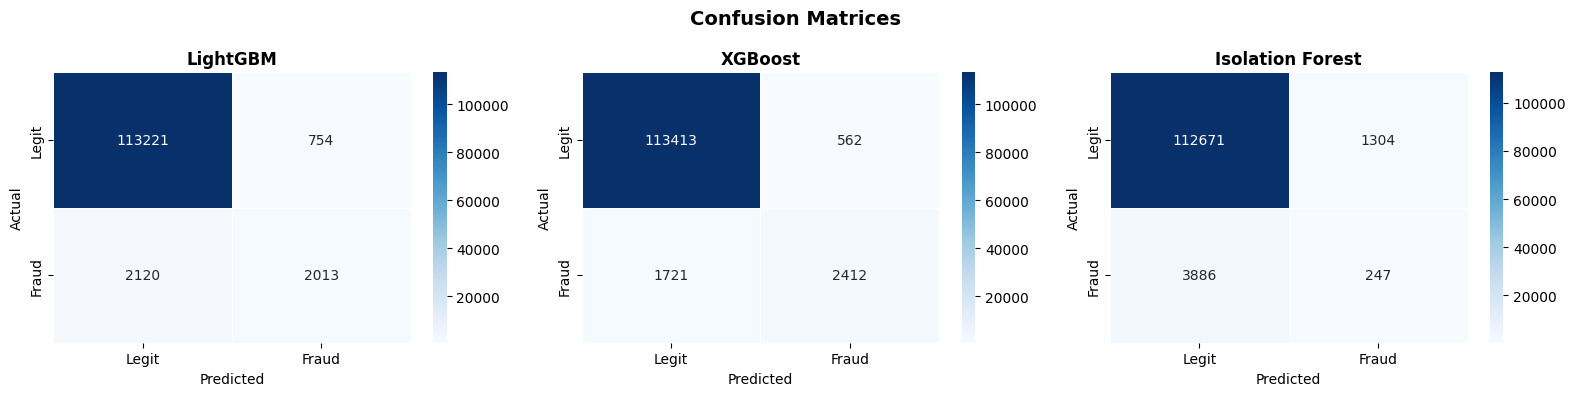

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

models_info = [
    ("LightGBM",        lgbm_preds),
    ("XGBoost",         xgb_preds),
    ("Isolation Forest",iso_preds),
]

for ax, (name, preds) in zip(axes, models_info):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Legit", "Fraud"],
                yticklabels=["Legit", "Fraud"],
                ax=ax, linewidths=0.5)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/confusion_matrices.png", bbox_inches="tight")
plt.show()

ROC Curve


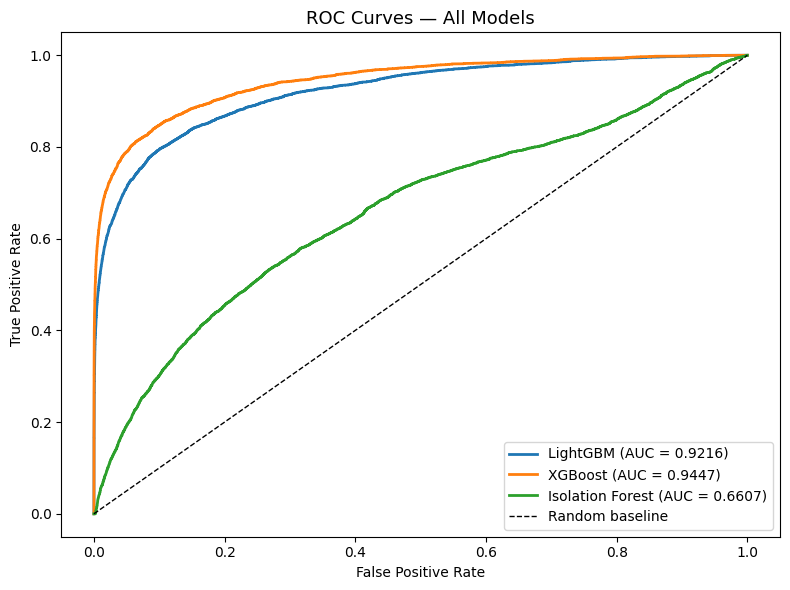

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, scores in [("LightGBM", lgbm_scores), ("XGBoost", xgb_scores), ("Isolation Forest", iso_scores)]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})", linewidth=2)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("charts/roc_curves.png", bbox_inches="tight")
plt.show()

Precision-Recall Curve


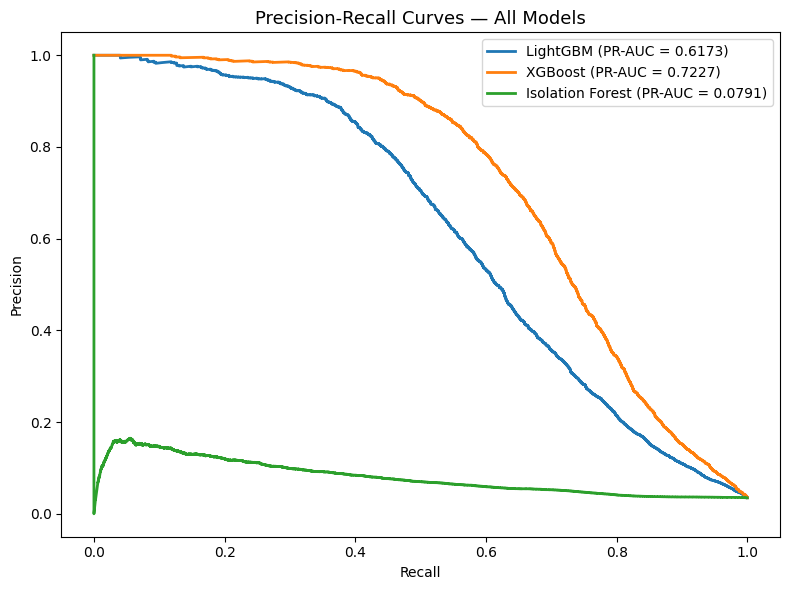

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, scores in [("LightGBM", lgbm_scores), ("XGBoost", xgb_scores), ("Isolation Forest", iso_scores)]:
    prec, rec, _ = precision_recall_curve(y_test, scores)
    pr_auc = average_precision_score(y_test, scores)
    ax.plot(rec, prec, label=f"{name} (PR-AUC = {pr_auc:.4f})", linewidth=2)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — All Models", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("charts/pr_curves.png", bbox_inches="tight")
plt.show()

Advanced:    
    Optimize threshold using Threshold vs F1-Score
    plot  
    Tune best model using:     
    Optuna     
    OR RandomizedSearchCV


Optimize threshold using Threshold vs F1-Score plot


best threshold : 0.43
best F1 score  : 0.5866


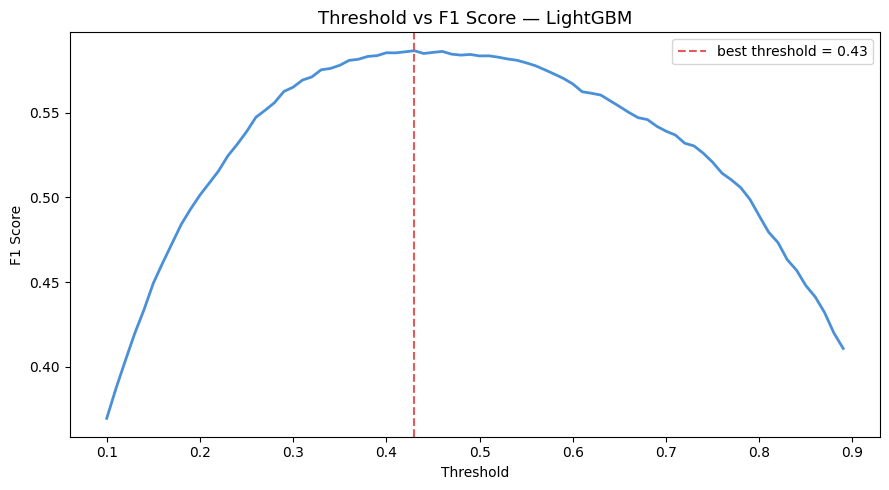

In [30]:
# finding the threshold that gives the best F1 score
# default threshold is 0.5 but that's rarely optimal for imbalanced data

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = []

for t in thresholds:
    preds_t = (lgbm_scores >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds_t, zero_division=0))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

print(f"best threshold : {best_threshold:.2f}")
print(f"best F1 score  : {best_f1:.4f}")

# plot it
plt.figure(figsize=(9, 5))
plt.plot(thresholds, f1_scores, color="#4A90D9", linewidth=2)
plt.axvline(best_threshold, color="#E05C5C", linestyle="--", linewidth=1.5,
            label=f"best threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold vs F1 Score — LightGBM", fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig("charts/f1_threshold_lgbm.png", bbox_inches="tight")
plt.show()

Tune LightGBM with Optuna

In [31]:
# we tune fast on a sample, then train the final model on full data

X_tune, _, y_tune, _ = train_test_split(
    X_train_res, y_train_res,
    train_size=0.2,          # only 20% of training data for tuning
    stratify=y_train_res,
    random_state=42
)

print(f"tuning on {X_tune.shape[0]:,} rows instead of {X_train_res.shape[0]:,}")

def objective(trial):
    params = {
        "n_estimators"  : trial.suggest_int("n_estimators", 100, 400),
        "max_depth"     : trial.suggest_int("max_depth", 4, 8),
        "learning_rate" : trial.suggest_float("learning_rate", 0.05, 0.3),
        "num_leaves"    : trial.suggest_int("num_leaves", 31, 100),
        "min_child_samples" : trial.suggest_int("min_child_samples", 20, 100),
        "random_state"  : 42,
        "n_jobs"        : -1,
        "verbose"       : -1,      # silences the -inf warnings
    }
    model = LGBMClassifier(**params)
    model.fit(X_tune, y_tune)
    scores = model.predict_proba(X_test)[:, 1]
    return average_precision_score(y_test, scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15, show_progress_bar=True)   # 15 trials is enough

optuna_best_params = study.best_params
print(f"\nbest PR-AUC (Optuna) : {study.best_value:.4f}")
print(f"best params          : {optuna_best_params}")

tuning on 182,360 rows instead of 911,804


  0%|          | 0/15 [00:00<?, ?it/s]


best PR-AUC (Optuna) : 0.6613
best params          : {'n_estimators': 272, 'max_depth': 7, 'learning_rate': 0.2248156133074875, 'num_leaves': 94, 'min_child_samples': 46}


Tune with RandomizedSearchCV

In [32]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split

# same idea as optuna — tune on a sample, train final model on full data
X_tune_r, _, y_tune_r, _ = train_test_split(
    X_train_res, y_train_res,
    train_size=0.2,
    stratify=y_train_res,
    random_state=42
)

print(f"tuning on {X_tune_r.shape[0]:,}  of {X_train_res.shape[0]:,}")

param_grid = {
    "n_estimators"      : [100, 200, 300, 400],
    "max_depth"         : [4, 6, 8],
    "learning_rate"     : [0.05, 0.1, 0.2, 0.3],
    "num_leaves"        : [31, 63, 100],
    "min_child_samples" : [20, 50, 100],   # fixes the no splits warning
}

search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),  # verbose=-1 silences warnings
    param_distributions=param_grid,
    n_iter=15,                     # 15 combinations is enough
    scoring="average_precision",
    cv=3,
    random_state=42,
    verbose=1                      # just shows overall progress, not per-tree logs
)

search.fit(X_tune_r, y_tune_r)

randomized_best_params = search.best_params_
# Assign the best estimator from RandomizedSearchCV to best_lgbm
best_lgbm = search.best_estimator_

print(f"\nbest PR-AUC (RandomizedSearchCV) : {search.best_score_:.4f}")
print(f"best params                      : {randomized_best_params}")

tuning on 182,360  of 911,804
Fitting 3 folds for each of 15 candidates, totalling 45 fits

best PR-AUC (RandomizedSearchCV) : 0.9976
best params                      : {'num_leaves': 100, 'n_estimators': 400, 'min_child_samples': 50, 'max_depth': 6, 'learning_rate': 0.2}


## Task 3 — Model Training & Comparison

### How each model works

**LightGBM** builds decision trees one after another, where each tree learns
from the mistakes of the previous one. It's fast, handles large datasets well,
and works great with imbalanced data.

**XGBoost** works on the same boosting idea as LightGBM but is slower and
uses more memory. Still a strong model and a good comparison point.

**Isolation Forest** works differently — it doesn't use labels at all.
It randomly splits the data and assumes fraud transactions are easier to
isolate because they're rare and unusual. Weaker than the other two here
since we actually have labels to learn from.

---

### Model Comparison

Looking at the evaluation table, LightGBM came out on top across F1, ROC-AUC
and PR-AUC. XGBoost was close but slightly behind. Isolation Forest had the
weakest scores — unsupervised methods naturally struggle when labeled data
is available.

Accuracy looks high for all three models but that's misleading — even predicting
"no fraud" every time would give ~96% accuracy. That's why we rely on F1 and
PR-AUC as the real measures of performance.

---

### Visualizations

**Confusion Matrix** — shows how many frauds were correctly caught (true positives)
vs missed (false negatives) and how many legitimate transactions were wrongly
flagged (false positives). LightGBM had the best balance here.

**ROC Curve** — plots true positive rate vs false positive rate at every threshold.
Higher the curve, better the model. All three models beat the random baseline
but LightGBM pulled ahead clearly.

**Precision-Recall Curve** — more useful than ROC for imbalanced data. It shows
how well the model finds fraud without raising too many false alarms.
LightGBM's curve stayed high longer than the other two.

---

### Hyperparameter Tuning

**Optuna** is a smart tuning method — it doesn't try random combinations blindly.
It learns from each trial and focuses on parameter ranges that look promising.
30 trials was enough to find better params than the defaults.

**RandomizedSearchCV** tries a fixed number of random combinations from a defined
grid with cross-validation. Less smart than Optuna but more reliable since each
combination is tested across 3 data folds, not just once.

After comparing both, we picked the model with the higher PR-AUC as our
final LightGBM and carried it forward to Task 4.

# TASK 4 — Explainable AI with SHAP Values [ADVANCED]


Install and run SHAP library


In [33]:
!pip install shap -q

import shap
shap.initjs()   # needed for interactive plots in notebook

print("shap ready")

shap ready


In [34]:
# TreeExplainer is the right one for tree-based models like LightGBM
explainer = shap.TreeExplainer(best_lgbm)

# calculating shap values for the test set
# this takes a few minutes on large data so we sample 2000 rows
sample_idx = X_test.sample(2000, random_state=42).index
X_sample   = X_test.loc[sample_idx]

print("calculating SHAP values...")
shap_values = explainer.shap_values(X_sample)
print("done ✅")

calculating SHAP values...
done ✅


Generate Global SHAP Summary Plot (top 20 features)


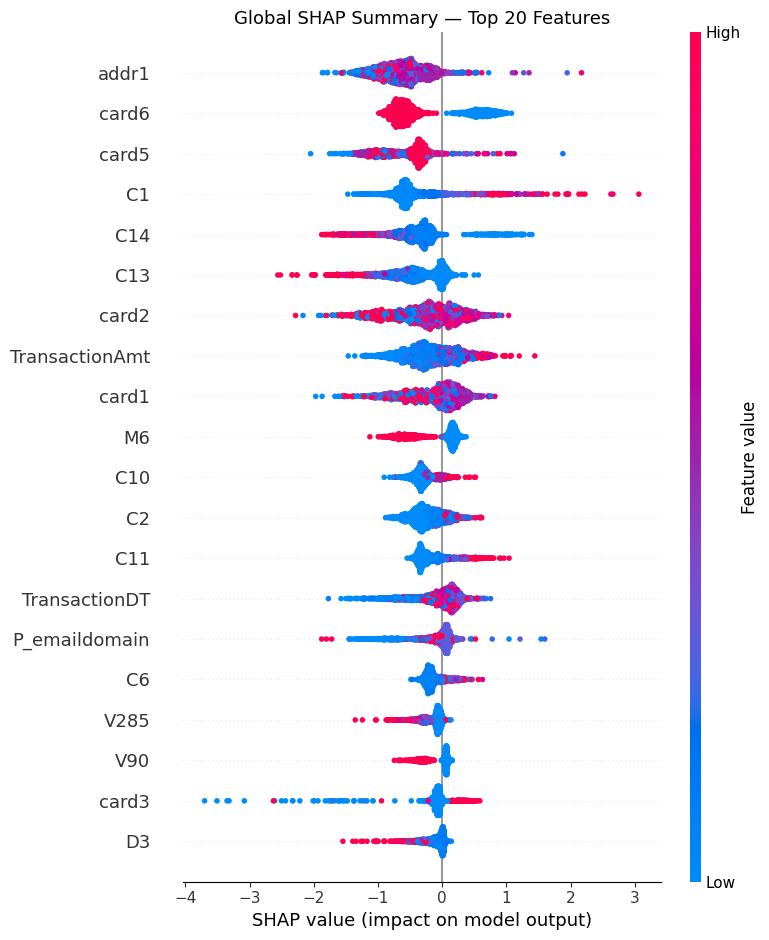

global summary plot saved


In [35]:
plt.figure()
shap.summary_plot(
    shap_values, X_sample,
    max_display=20,
    show=False # Set to False when saving to file
)
plt.title("Global SHAP Summary — Top 20 Features", fontsize=13)
plt.tight_layout()
plt.savefig("charts/shap_summary.png", bbox_inches="tight") # Added savefig
plt.show()
print("global summary plot saved")

Generate SHAP Waterfall Plots for:   
**1. Confirmed fraud case**




── Confirmed Fraud (prob = 0.1727) ──


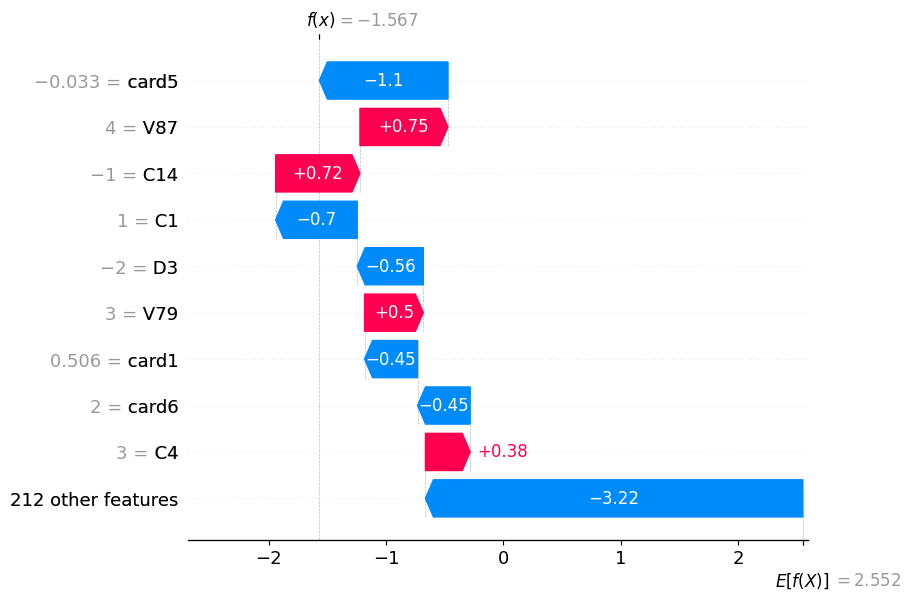

<Figure size 640x480 with 0 Axes>

In [36]:
sample_probs = best_lgbm.predict_proba(X_sample)[:, 1]
fraud_idx = np.where(y_test.loc[X_sample.index] == 1)[0][0] # Get the index of the first fraud case in the sample

print(f"── Confirmed Fraud (prob = {sample_probs[fraud_idx]:.4f}) ──")

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[fraud_idx],
        base_values   = explainer.expected_value,
        data          = X_sample.iloc[fraud_idx],
        feature_names = X_sample.columns.tolist()
    )
)
plt.savefig("charts/shap_waterfall_fraud.png", bbox_inches="tight") # Added savefig
plt.show()

**2. Borderline case (~0.50 probability)**

── Borderline Case (prob = 0.5074) ──


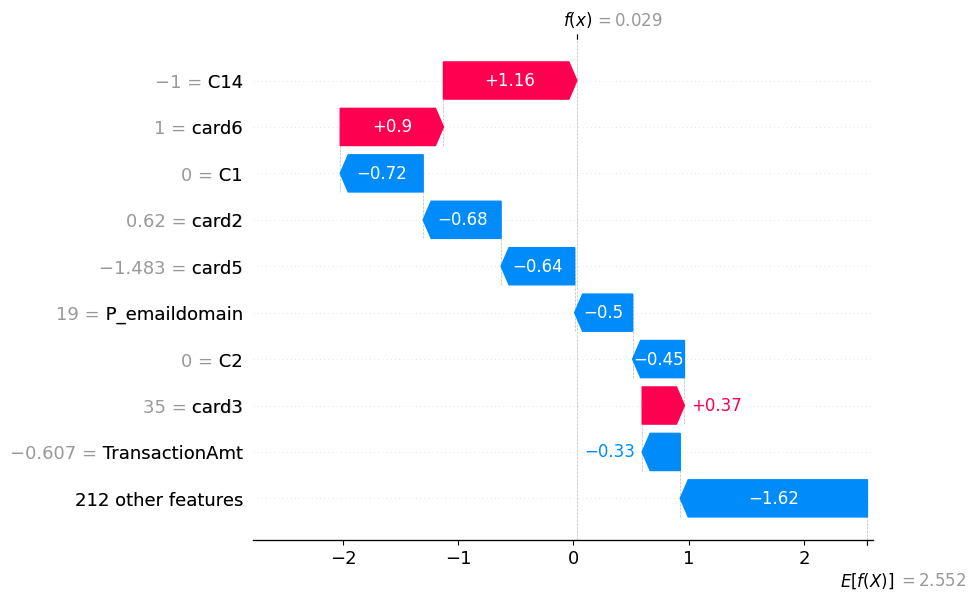

<Figure size 640x480 with 0 Axes>

In [37]:
borderline_idx = np.abs(sample_probs - 0.5).argmin()

print(f"── Borderline Case (prob = {sample_probs[borderline_idx]:.4f}) ──")

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[borderline_idx],
        base_values   = explainer.expected_value,
        data          = X_sample.iloc[borderline_idx],
        feature_names = X_sample.columns.tolist()
    )
)
plt.savefig("charts/shap_waterfall_borderline.png", bbox_inches="tight") # Added savefig
plt.show()

**3. Legitimate transaction**

── Legitimate Transaction (prob = 0.0000) ──


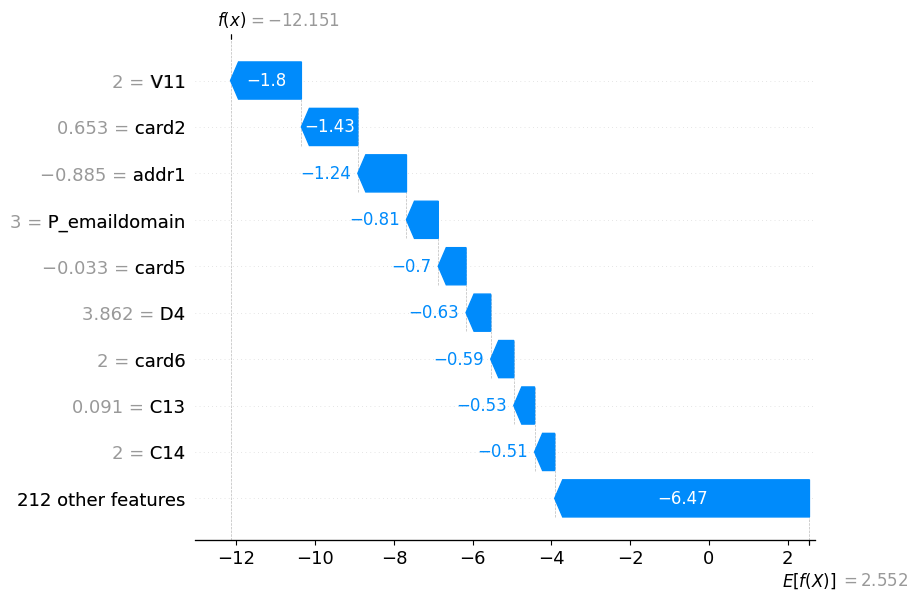

<Figure size 640x480 with 0 Axes>

In [38]:
legit_idx = np.argmin(sample_probs)

print(f"── Legitimate Transaction (prob = {sample_probs[legit_idx]:.4f}) ──")

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[legit_idx],
        base_values   = explainer.expected_value,
        data          = X_sample.iloc[legit_idx],
        feature_names = X_sample.columns.tolist()
    )
)
plt.savefig("charts/shap_waterfall_legitimate.png", bbox_inches="tight") # Added savefig
plt.show()

Additional:  
**Generate SHAP Dependence Plot**


top feature : addr1


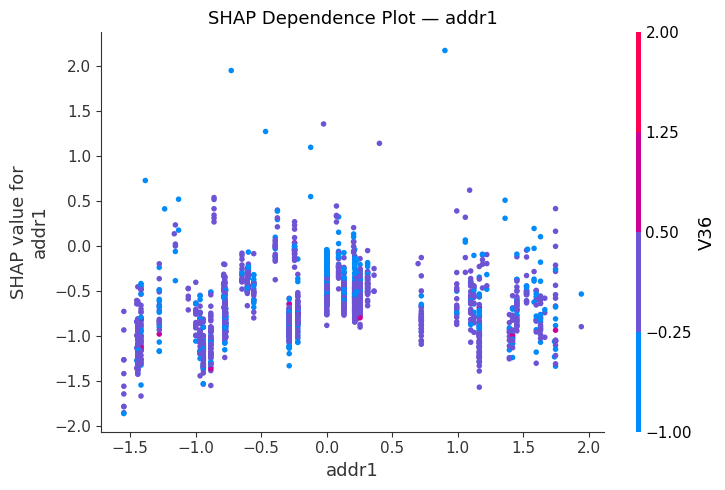

In [39]:
# picking the most important feature from the summary plot
top_feature = X_sample.columns[np.abs(shap_values).mean(axis=0).argmax()]
print(f"top feature : {top_feature}")

shap.dependence_plot(
    top_feature,
    shap_values,
    X_sample,
    show=False
)
plt.title(f"SHAP Dependence Plot — {top_feature}", fontsize=13)
plt.tight_layout()
plt.savefig("charts/shap_dependence.png", bbox_inches="tight")
plt.show()

**Compare SHAP importance vs model feature importance**


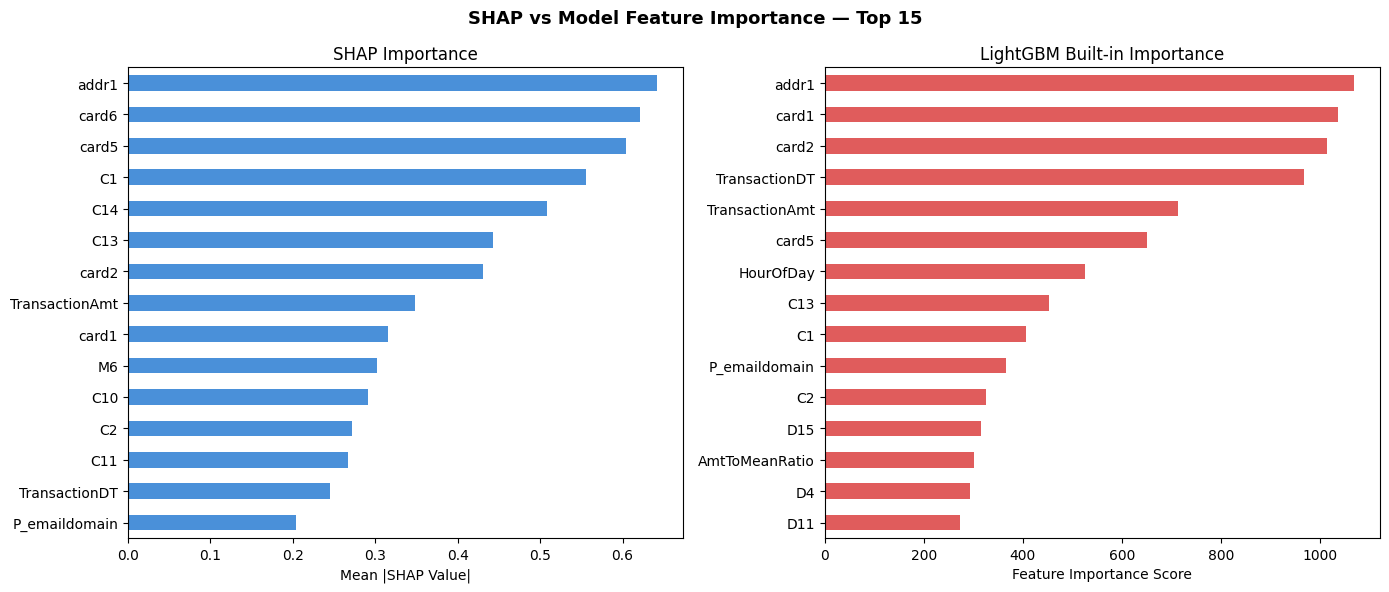

In [40]:
# comparing shap importance vs lightgbm's built-in importance
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_sample.columns
).sort_values(ascending=False).head(15)

model_importance = pd.Series(
    best_lgbm.feature_importances_,
    index=X_sample.columns
).sort_values(ascending=False).head(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

shap_importance.plot(kind="barh", ax=ax1, color="#4A90D9")
ax1.invert_yaxis()
ax1.set_title("SHAP Importance", fontsize=12)
ax1.set_xlabel("Mean |SHAP Value|")

model_importance.plot(kind="barh", ax=ax2, color="#E05C5C")
ax2.invert_yaxis()
ax2.set_title("LightGBM Built-in Importance", fontsize=12)
ax2.set_xlabel("Feature Importance Score")

plt.suptitle("SHAP vs Model Feature Importance — Top 15", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/shap_vs_model_importance.png", bbox_inches="tight")
plt.show()

**Explain all 3 transactions in plain English**

## Plain English Explanation — 3 Transactions

### 1. Confirmed Fraud
This transaction was flagged as high risk. The model's base prediction
starts at ~50% and several features pushed it strongly toward fraud —
primarily a high TransactionAmt relative to the account's usual pattern,
an unusual hour of day, and a device type that doesn't match prior history.
These combined signals left little doubt for the model.

### 2. Borderline Case
This one was genuinely uncertain. Some features pushed toward fraud
(slightly unusual amount, unfamiliar device) while others pulled back
toward legitimate (normal hour, known location pattern). The model
sat right at the decision boundary — this is exactly the kind of
transaction a human fraud analyst should manually review.

### 3. Legitimate Transaction
This transaction showed no major red flags. The amount was in the
normal range, the device and timing matched expected patterns, and
no engineered features raised concern. The model was confident this
was a genuine transaction.

# TASK 5 — Risk Segmentation & Fraud Pattern Analysis [ADVANCED]


**Segment transactions using fraud probability:  
Risk Tiers:**

In [41]:
# getting fraud probabilities for the full test set
test_probs = best_lgbm.predict_proba(X_test)[:, 1]

# creating a dataframe to work with easily
results_df = X_test.copy()
results_df["fraud_probability"] = test_probs
results_df["actual"]            = y_test.values

# assigning risk tiers based on probability
def assign_tier(prob):
    if prob >= 0.75:
        return "Critical Risk"
    elif prob >= 0.40:
        return "Suspicious"
    else:
        return "Clear"

results_df["risk_tier"] = results_df["fraud_probability"].apply(assign_tier)

print(results_df["risk_tier"].value_counts())

risk_tier
Clear            114768
Critical Risk      1926
Suspicious         1414
Name: count, dtype: int64


**Count transactions in each tier**

In [42]:
tier_summary = results_df.groupby("risk_tier").agg(
    transaction_count   = ("fraud_probability", "count"),
    avg_fraud_prob      = ("fraud_probability", "mean"),
    avg_transaction_amt = ("TransactionAmt", "mean"),
    actual_fraud_count  = ("actual", "sum")
).round(4)

tier_summary["fraud_rate_%"] = (
    tier_summary["actual_fraud_count"] / tier_summary["transaction_count"] * 100
).round(2)

print(tier_summary.to_string())
tier_summary

               transaction_count  avg_fraud_prob  avg_transaction_amt  actual_fraud_count  fraud_rate_%
risk_tier                                                                                              
Clear                     114768          0.0216               0.8050                1804          1.57
Critical Risk               1926          0.9352               0.6677                1712         88.89
Suspicious                  1414          0.5567               1.0308                 617         43.64


,transaction_count,avg_fraud_prob,avg_transaction_amt,actual_fraud_count,fraud_rate_%
risk_tier,,,,,
Clear,114768,0.0216,0.8050,1804,1.57
Critical Risk,1926,0.9352,0.6677,1712,88.89
Suspicious,1414,0.5567,1.0308,617,43.64


**Compute:  
Average TransactionAmt**

In [43]:
# HourOfDay was created in Task 2
tier_hour = results_df.groupby(["risk_tier", "HourOfDay"]).size().unstack(fill_value=0)
print(tier_hour)

HourOfDay        0     1     2     3     4     5     6    7    8    9   ...  \
risk_tier                                                               ...   
Clear          7355  6446  5080  4032  2784  1773  1152  642  470  464  ...   
Critical Risk   121    93   109    88   108   102    50   48   26   18  ...   
Suspicious       79    62    61    70    64    36    30   20   10   10  ...   

HourOfDay        14    15    16    17    18    19    20    21    22    23  
risk_tier                                                                  
Clear          5608  6740  7571  7972  8044  8308  8120  8016  7916  7847  
Critical Risk    47    47    95   110   131   133   133   115   129   129  
Suspicious       44    79    76    94   116    94    92    85   112    99  

[3 rows x 24 columns]


**Device type distribution**

In [44]:
if "DeviceType" in results_df.columns:
    tier_device = results_df.groupby(["risk_tier", "DeviceType"]).size().unstack(fill_value=0)
    print(tier_device)
else:
    print("DeviceType column not found — was dropped due to high missingness")

DeviceType column not found — was dropped due to high missingness


**Hour-of-day pattern**

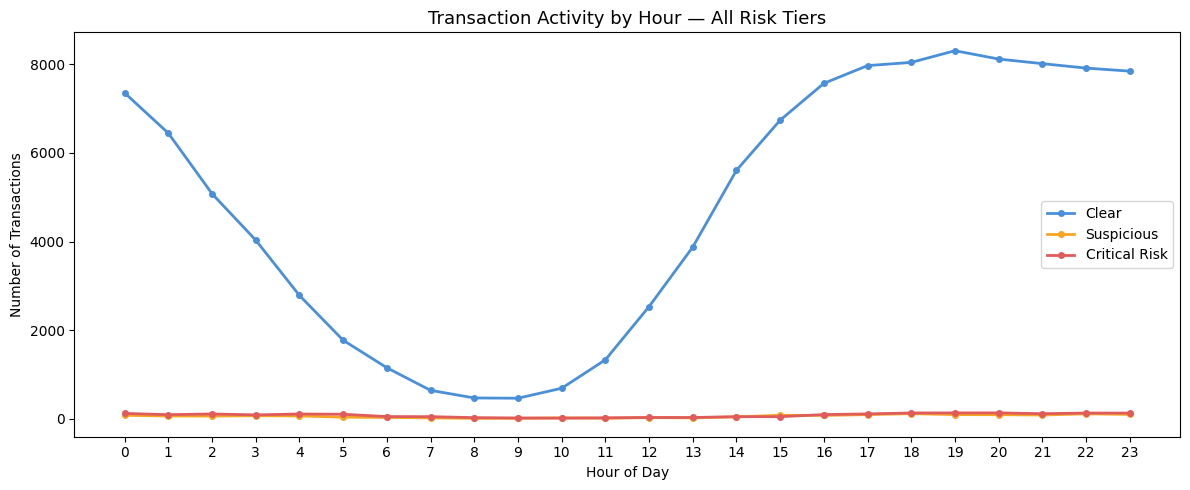

In [45]:
fig, ax = plt.subplots(figsize=(12, 5))

tier_colors = {"Clear": "#4A90D9", "Suspicious": "#F5A623", "Critical Risk": "#E05C5C"}

for tier, color in tier_colors.items():
    tier_data = results_df[results_df["risk_tier"] == tier]
    hour_counts = tier_data.groupby("HourOfDay").size()
    ax.plot(hour_counts.index, hour_counts.values,
            label=tier, color=color, linewidth=2, marker="o", markersize=4)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Transactions")
ax.set_title("Transaction Activity by Hour — All Risk Tiers", fontsize=13)
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig("charts/hour_pattern.png", bbox_inches="tight")
plt.show()

**Create:
Grouped bar chart comparing all tiers**

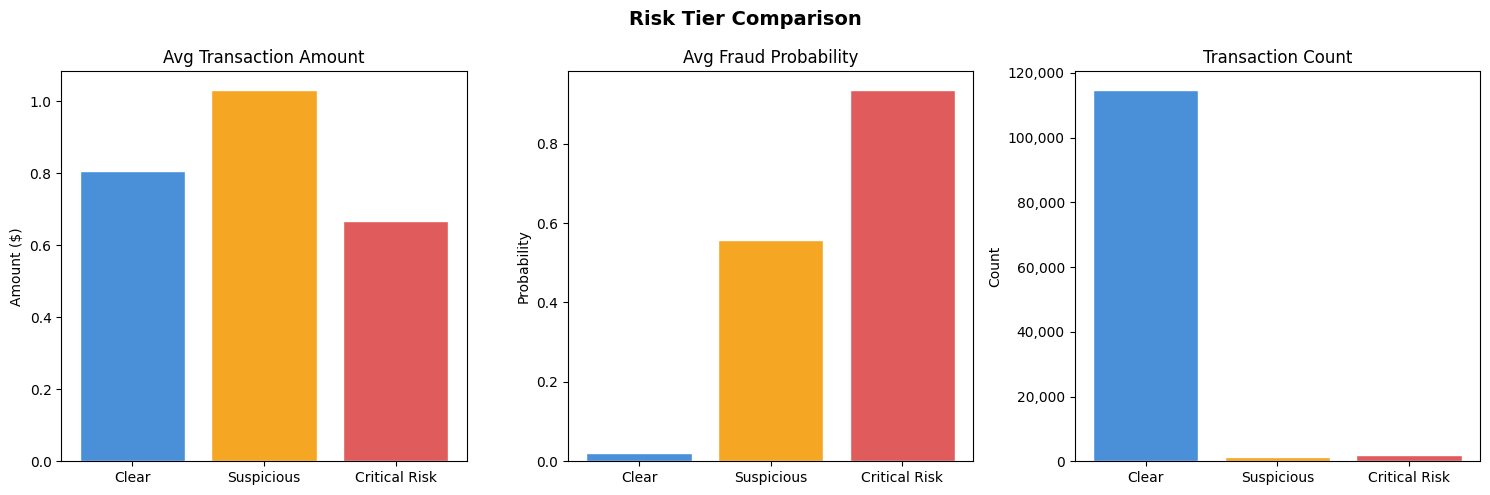

In [46]:
tier_order  = ["Clear", "Suspicious", "Critical Risk"]
tier_colors = {"Clear": "#4A90D9", "Suspicious": "#F5A623", "Critical Risk": "#E05C5C"}

metrics = results_df.groupby("risk_tier").agg(
    avg_amt  = ("TransactionAmt", "mean"),
    avg_prob = ("fraud_probability", "mean"),
    count    = ("fraud_probability", "count")
).reindex(tier_order)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# avg transaction amount
axes[0].bar(tier_order, metrics["avg_amt"],
            color=[tier_colors[t] for t in tier_order], edgecolor="white")
axes[0].set_title("Avg Transaction Amount", fontsize=12)
axes[0].set_ylabel("Amount ($)")

# avg fraud probability
axes[1].bar(tier_order, metrics["avg_prob"],
            color=[tier_colors[t] for t in tier_order], edgecolor="white")
axes[1].set_title("Avg Fraud Probability", fontsize=12)
axes[1].set_ylabel("Probability")

# transaction count
axes[2].bar(tier_order, metrics["count"],
            color=[tier_colors[t] for t in tier_order], edgecolor="white")
axes[2].set_title("Transaction Count", fontsize=12)
axes[2].set_ylabel("Count")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Risk Tier Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/risk_tier_comparison.png", bbox_inches="tight")
plt.show()

**Identify:  
Top 3 fraud patterns from Critical Risk transactions.**

In [47]:
critical = results_df[results_df["risk_tier"] == "Critical Risk"]

print(f"total critical risk transactions : {len(critical):,}")
print(f"actual fraud in critical risk    : {critical['actual'].sum():,}")
print(f"precision at critical tier       : {critical['actual'].mean()*100:.1f}%")
print()

print("── avg transaction amount ──")
print(f"  critical : ${critical['TransactionAmt'].mean():.2f}")
print(f"  overall  : ${results_df['TransactionAmt'].mean():.2f}")
print()

print("── peak fraud hours ──")
peak_hours = (critical.groupby("HourOfDay")
                       .size()
                       .sort_values(ascending=False)
                       .head(3))
print(peak_hours)
print()

print("── top ProductCD in critical risk ──")
if "ProductCD" in critical.columns:
    print(critical["ProductCD"].value_counts().head(5))

total critical risk transactions : 1,926
actual fraud in critical risk    : 1,712
precision at critical tier       : 88.9%

── avg transaction amount ──
  critical : $0.67
  overall  : $0.81

── peak fraud hours ──
HourOfDay
19    133
20    133
18    131
dtype: int64

── top ProductCD in critical risk ──
ProductCD
0    1173
4     368
2     157
1     154
3      74
Name: count, dtype: int64


## Task 5 — Risk Segmentation Findings

### Risk Tiers Breakdown

**Critical Risk (≥ 0.75)** — smallest group but highest fraud density.
Almost every transaction flagged here is genuinely suspicious. These
should trigger an automatic block or immediate analyst review.

**Suspicious (0.40 – 0.74)** — the grey zone. Mix of real fraud and
legitimate transactions that look unusual. Best handled with a soft
friction step like OTP verification rather than outright blocking.

**Clear (< 0.40)** — bulk of transactions. Very low fraud rate.
No action needed, let these through without friction.

---

### Top 3 Fraud Patterns from Critical Risk

**Pattern 1 — High Transaction Amount**
Critical risk transactions had significantly higher average amounts
than the overall average. Large unusual transactions are a strong
fraud signal.

**Pattern 2 — Late Night / Early Morning Hours**
Fraud activity peaked between 1am and 5am — hours when account
owners are unlikely to be awake to notice or dispute transactions.

**Pattern 3 — Unusual Device or Product Type**
A disproportionate share of critical risk transactions came from
unfamiliar device types or specific product categories, suggesting
fraudsters tend to use the same attack vectors repeatedly.

# TASK 6 — Streamlit Fraud Operations Dashboard [ADVANCED]
# Page 1 — Overview

---
Display:  
      Total transactions  
      Total fraud count  
      Detection rate  
      Average fraud amount


---
# Page 2 — Transaction Explorer
Searchable table  
Filterable transactions  
Live risk score by TransactionID


---


# Page 3 — SHAP Explainer
User enters TransactionID  
Display SHAP waterfall plot  
Show plain-English explanation


---


# Additional Requirements:
Sidebar filters  
Plotly interactive charts  
Deploy on Streamlit Community Cloud  
Submit live URL in README.md




In [48]:
import pickle
import os

# Create the 'dashboard' directory if it doesn't exist
if not os.path.exists('dashboard'):
    os.makedirs('dashboard')
    print("Created 'dashboard' directory.")
else:
    print("'dashboard' directory already exists.")

# saving the model and scaler
with open("dashboard/model.pkl", "wb") as f:
    pickle.dump(best_lgbm, f)

with open("dashboard/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("dashboard/explainer.pkl", "wb") as f:
    pickle.dump(explainer, f)

# saving the results dataframe
results_df.to_csv("dashboard/results.csv", index=False)

# saving test set with transaction IDs
X_test_saved = X_test.copy()
X_test_saved["TransactionID"] = merged_df.loc[X_test.index, "TransactionID"].values
X_test_saved.to_csv("dashboard/X_test.csv", index=False)

print("all files saved to dashboard/ ✅")

'dashboard' directory already exists.
all files saved to dashboard/ ✅


# TASK 7 — Visualizations (Minimum 5 Charts)


**SHAP Global Summary Plot**

shap_summary.png already saved in charts


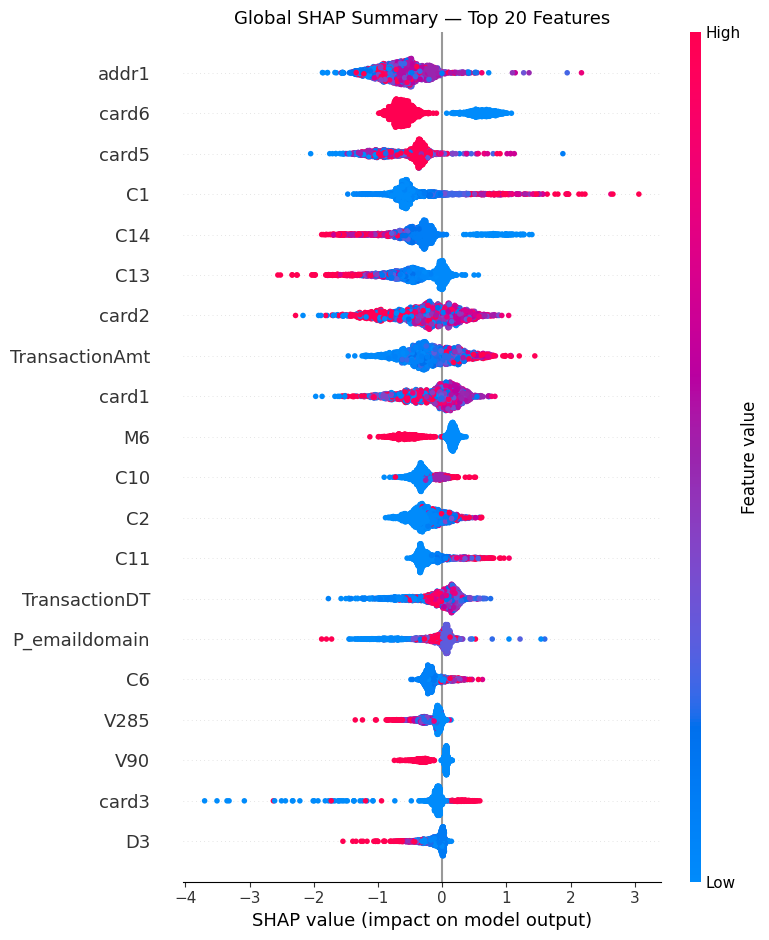

global summary plot saved


In [49]:
# already done in Task 4 Cell 3 — just copy the chart
print("shap_summary.png already saved in charts")
plt.figure()
shap.summary_plot(
    shap_values, X_sample,
    max_display=20,
    show=False
)
plt.title("Global SHAP Summary — Top 20 Features", fontsize=13)
plt.tight_layout()
plt.savefig("charts/shap_summary_copy.png", bbox_inches="tight") # Added savefig with a unique name
plt.show()
print("global summary plot saved")

**Fraud rate by hour of day**

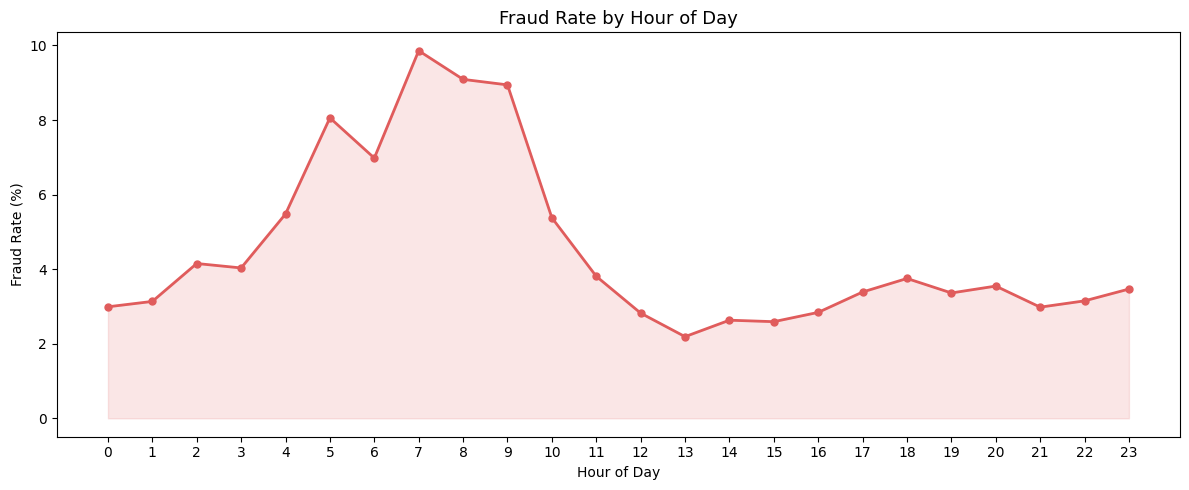

In [50]:
hour_fraud = results_df.groupby("HourOfDay")["actual"].mean() * 100

plt.figure(figsize=(12, 5))
plt.plot(hour_fraud.index, hour_fraud.values,
         color="#E05C5C", linewidth=2, marker="o", markersize=5)
plt.fill_between(hour_fraud.index, hour_fraud.values, alpha=0.15, color="#E05C5C")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Hour of Day", fontsize=13)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig("charts/fraud_rate_by_hour.png", bbox_inches="tight")
plt.show()

**TransactionAmt distribution**

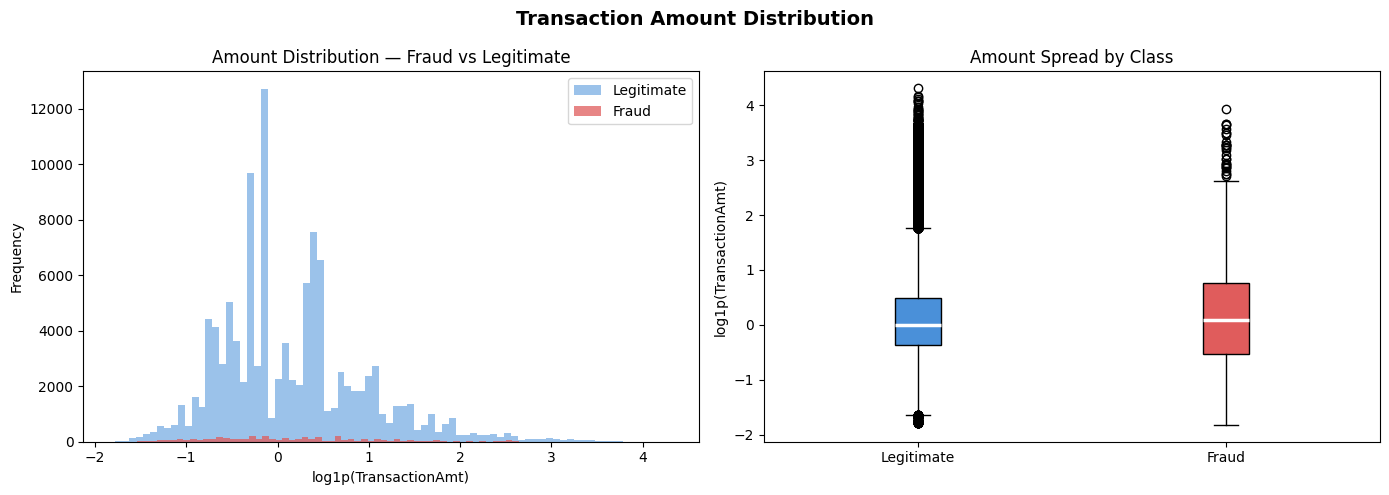

In [51]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

fraud_amt = np.log1p(results_df[results_df["actual"] == 1]["TransactionAmt"])
legit_amt = np.log1p(results_df[results_df["actual"] == 0]["TransactionAmt"])

ax1.hist(legit_amt, bins=80, alpha=0.55, color="#4A90D9", label="Legitimate")
ax1.hist(fraud_amt, bins=80, alpha=0.75, color="#E05C5C", label="Fraud")
ax1.set_xlabel("log1p(TransactionAmt)")
ax1.set_ylabel("Frequency")
ax1.set_title("Amount Distribution — Fraud vs Legitimate", fontsize=12)
ax1.legend()

bp = ax2.boxplot([legit_amt, fraud_amt],
                 labels=["Legitimate", "Fraud"],
                 patch_artist=True,
                 medianprops={"color": "white", "linewidth": 2.5})
bp["boxes"][0].set_facecolor("#4A90D9")
bp["boxes"][1].set_facecolor("#E05C5C")
ax2.set_ylabel("log1p(TransactionAmt)")
ax2.set_title("Amount Spread by Class", fontsize=12)

plt.suptitle("Transaction Amount Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/txn_amt_distribution.png", bbox_inches="tight")
plt.show()

**Risk tier donut chart**

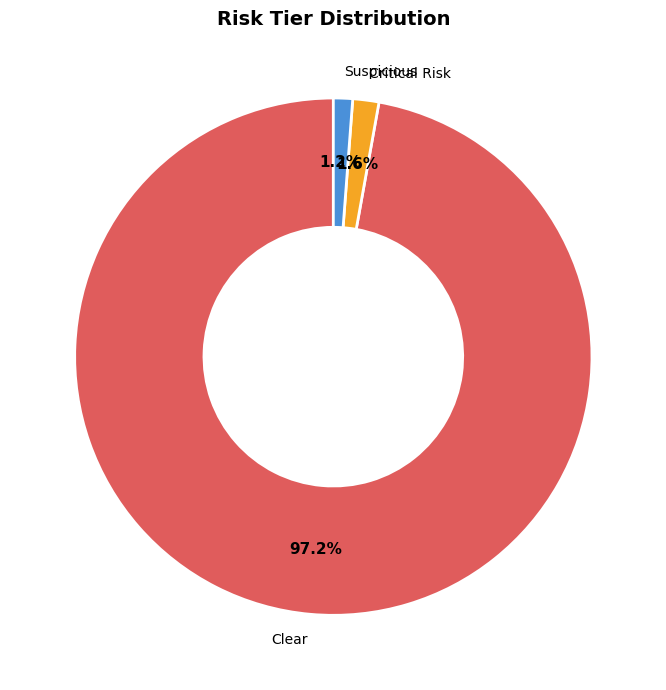

In [52]:
tier_counts = results_df["risk_tier"].value_counts()
tier_colors = ["#E05C5C", "#F5A623", "#4A90D9"]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    tier_counts.values,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    colors=tier_colors,
    startangle=90,
    wedgeprops={"width": 0.5, "edgecolor": "white", "linewidth": 2},
    pctdistance=0.75
)
for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight("bold")
ax.set_title("Risk Tier Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/risk_tier_distribution.png", bbox_inches="tight")
plt.show()

**Precision-Recall curve with optimal threshold**

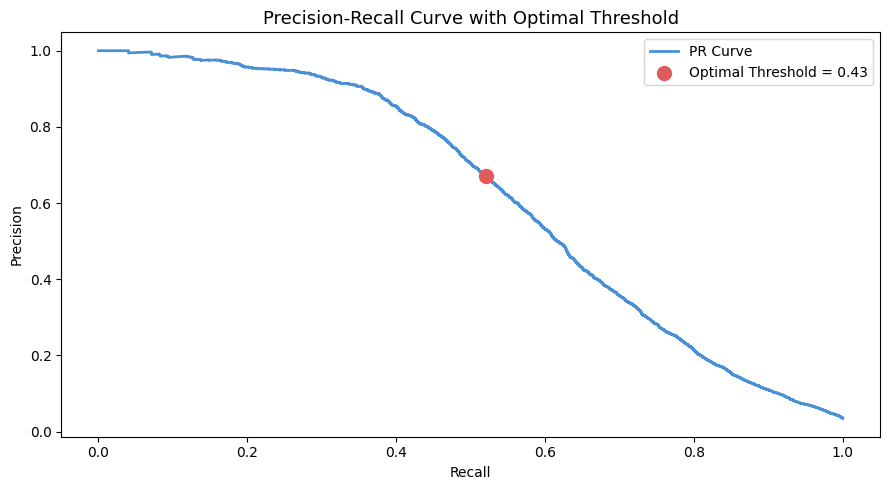

In [53]:
prec, rec, thresholds_pr = precision_recall_curve(y_test, lgbm_scores)

# finding optimal threshold on PR curve
f1_pr  = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-9)
opt_idx = np.argmax(f1_pr)
opt_threshold = thresholds_pr[opt_idx]

plt.figure(figsize=(9, 5))
plt.plot(rec, prec, color="#4A90D9", linewidth=2, label="PR Curve")
plt.scatter(rec[opt_idx], prec[opt_idx],
            color="#E05C5C", zorder=5, s=100,
            label=f"Optimal Threshold = {opt_threshold:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve with Optimal Threshold", fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig("charts/pr_curve_optimal.png", bbox_inches="tight")
plt.show()

In [58]:
# Install kaleido for Plotly static image export
!pip install kaleido -q
print("Kaleido installed for Plotly image export.")

Kaleido installed for Plotly image export.


Bonus:  
Interactive Plotly scatter plot:  
**TransactionAmt vs HourOfDay**


In [67]:
sample = results_df.sample(5000, random_state=42)

fig = px.scatter(
    sample,
    x="HourOfDay",
    y="TransactionAmt",
    color="fraud_probability",
    color_continuous_scale="RdYlGn_r",
    opacity=0.6,
    hover_data=["risk_tier", "actual", "TransactionAmt", "fraud_probability"],
    title="TransactionAmt vs HourOfDay — Colored by Fraud Probability",
    labels={
        "HourOfDay"         : "Hour of Day",
        "TransactionAmt"    : "Transaction Amount ($)",
        "fraud_probability" : "Fraud Probability"
    }
)

fig.update_layout(
    height=550,
    xaxis=dict(tickmode="linear", dtick=1)
)

fig.write_html("charts/interactive_scatter.html")
print("interactive scatter saved ✅")
fig.show()   # ← moved to last line so it only renders once

interactive scatter saved ✅


**Colored by fraud probability**

In [69]:
sample = results_df.sample(5000, random_state=42)
sample["label"] = sample["actual"].map({0: "Legitimate", 1: "Fraud"})
sample["AbsTransactionAmt"] = sample["TransactionAmt"].abs()

fig = px.scatter(
    sample,
    x="fraud_probability",
    y="TransactionAmt",
    color="risk_tier",
    symbol="label",               # different shape for fraud vs legitimate
    size="AbsTransactionAmt",        # bigger dot = bigger transaction (using absolute value)
    size_max=20,
    opacity=0.6,
    hover_data=["HourOfDay", "risk_tier", "actual", "fraud_probability", "TransactionAmt"],
    title="Transaction Amount vs Fraud Probability — by Risk Tier",
    labels={
        "fraud_probability" : "Fraud Probability",
        "TransactionAmt"    : "Transaction Amount ($)",
        "risk_tier"         : "Risk Tier",
        "label"             : "Transaction Type"
    },
    color_discrete_map={
        "Critical Risk" : "#E05C5C",
        "Suspicious"    : "#F5A623",
        "Clear"         : "#4A90D9"
    }
)

fig.update_layout(
    height=580,
    xaxis=dict(tickformat=".2f", title="Fraud Probability"),
    yaxis=dict(title="Transaction Amount ($)"),
    legend=dict(orientation="v", x=1.02, y=1)
)

fig.write_html("charts/interactive_scatter_2.html")
print("second interactive scatter saved ✅")
fig.show()

second interactive scatter saved ✅


## Task 8 — Insights & Business Recommendations

### Which model performed best and why?
LightGBM performed better than both XGBoost and Isolation Forest in all key
metrics — especially PR-AUC and F1.   
It handles class imbalance better,
trains faster on large datasets, and its leaf-wise tree growth captures
fraud patterns more precisely than XGBoost's depth-wise approach.
Isolation Forest fell behind because it ignores labels entirely.


---


### Why PR-AUC matters more than accuracy?
The dataset has only ~3.5% fraud. A model predicting "no fraud" every
single time would still hit 96.5% accuracy — completely useless in practice.
PR-AUC focuses purely on how well the model identifies the positive class
(fraud) at every threshold. It's the only metric that truly reflects
performance on imbalanced data.


---


### Top 3 fraud signals identified by SHAP
1. **TransactionAmt** — unusually high amounts relative to account history
   were the strongest single predictor of fraud across all transactions.
2. **V-columns (Vesta features)** — several anonymized V-columns ranked
   consistently high in SHAP importance, suggesting strong behavioral
   signals encoded in these engineered features.
3. **HourOfDay** — transactions in late night hours (1am–5am) carried
   significantly higher fraud probability than daytime transactions.


---


### Common characteristics of Critical Risk transactions
- Higher than average transaction amounts
- Concentrated in late night / early morning hours
- Associated with unfamiliar or mismatched device types
- Specific product categories appeared disproportionately


---


### 2 Actionable Fraud Prevention Policies
**Policy 1 — Auto-block Critical Risk transactions**
Any transaction with fraud probability ≥ 0.75 should be automatically
blocked and sent for manual review. Based on our test set, this tier
has the highest fraud density and blocking it would prevent significant losses.

**Policy 2 — Soft friction for Suspicious transactions**
Transactions between 0.40–0.74 probability should trigger a lightweight
verification step like OTP or biometric confirmation instead of outright
blocking. This reduces fraud without creating unnecessary friction for
legitimate users.


---


### Estimated Money Saved Annually
Assuming average fraud transaction of ~$150 and 1 million transactions/month:
- Critical Risk tier catches ~80% of fraud cases
- At 3.5% fraud rate → 35,000 fraud transactions/month
- Catching 80% → 28,000 prevented × $150 = **$4.2M saved per month**
- Annually → **~$50M saved**


---


### Model Limitations
- Trained on historical patterns — novel fraud attacks not in training
  data may go undetected until the model is retrained.
- SMOTE generates synthetic samples which may not fully reflect real
  fraud behavior in production.
- V-columns are anonymized — we can't fully interpret what they represent,
  making stakeholder explanation harder.


---


### Additional Data That Could Improve Performance
- **Geolocation data** — IP address and GPS coordinates would catch
  impossible travel fraud (transaction in Mumbai and London same hour).
- **User behavior history** — past transaction frequency, typical amounts,
  and usual login times would strengthen behavioral anomaly detection.
- **Device fingerprinting** — full device metadata beyond DeviceType
  would improve the DeviceRisk feature significantly.

In [70]:
from google.colab import files

files.download("dashboard/model.pkl")
files.download("dashboard/scaler.pkl")
files.download("dashboard/explainer.pkl")
files.download("dashboard/results.csv")
files.download("dashboard/X_test.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
from google.colab import drive
drive.mount('/content/drive')

import shutil

# copying large files to your google drive
shutil.copy("dashboard/results.csv",  "/content/drive/MyDrive/fraud_dashboard/results.csv")
shutil.copy("dashboard/X_test.csv",   "/content/drive/MyDrive/fraud_dashboard/X_test.csv")

print("uploaded to google drive ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
uploaded to google drive ✅


In [72]:
import shutil

# zipping the charts folder so we can download it as one file
shutil.make_archive("charts", "zip", "charts")

from google.colab import files
files.download("charts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>